In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow.keras.layers import Dense , MaxPooling2D , Dropout , Conv2D , Flatten
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR_train = r"/content/drive/MyDrive/X-Ray_Image_Classification/chest_xray/train"
DATA_DIR_test = r"/content/drive/MyDrive/X-Ray_Image_Classification/chest_xray/test"
DATA_DIR_val = r"/content/drive/MyDrive/X-Ray_Image_Classification/chest_xray/pred"

In [ ]:
CATEGORIES = ['NORMAL' , 'PNEUMONIA']

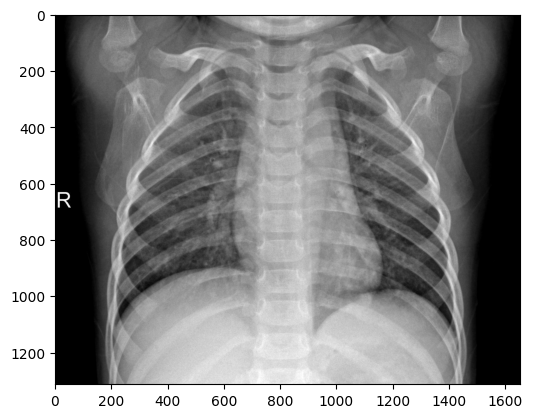

In [ ]:
#converting images to grayscale

for i in CATEGORIES :
  path = os.path.join(DATA_DIR_train ,i)
  for img in os.listdir(path) :
    img_array = cv2.imread(os.path.join(path,img) , cv2.IMREAD_GRAYSCALE)
    plt.imshow(img_array , cmap = "gray")
    plt.show()
    break
  break

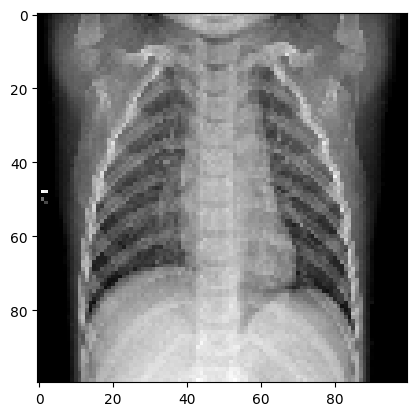

In [ ]:
img_size = 100
new_array = cv2.resize(img_array , (img_size,img_size))
plt.imshow(new_array , cmap = "gray")
plt.show()

In [ ]:
training_data = []

In [ ]:
def create_training_dataset():
  for i in CATEGORIES:
    path = os.path.join(DATA_DIR_train , i)
    classIndex = CATEGORIES.index(i)
    for img in os.listdir(path) :
      imgTemp_array = cv2.imread(os.path.join(path,img) , cv2.IMREAD_GRAYSCALE)
      newTemp__array = cv2.resize(imgTemp_array , (img_size,img_size))
      training_data.append([newTemp__array,classIndex])

In [ ]:
create_training_dataset()

In [ ]:
len(training_data)

7315

In [ ]:
import random
random.shuffle(training_data)
print(training_data[:10])

[[array([[  0,   0,   0, ..., 166,  93,  85],
       [  0,   0,   0, ...,  94,  93,  83],
       [  0,   0,   0, ...,  92,  94,  84],
       ...,
       [  0,   0,  53, ...,   0,   0,   0],
       [  0,   0,  51, ...,   0,   0,   0],
       [  0,   0,  46, ...,   0,   0,   0]], dtype=uint8), 0], [array([[ 0,  0,  0, ..., 38, 24,  1],
       [ 0,  0,  0, ..., 32, 22,  1],
       [ 0,  0,  0, ..., 33, 20,  1],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 0], [array([[10, 10,  7, ..., 54, 56, 17],
       [ 9,  8,  7, ..., 53, 64, 57],
       [ 9,  7,  7, ..., 66, 59, 80],
       ...,
       [22, 16, 13, ..., 77, 85, 27],
       [13, 16, 14, ..., 36, 24, 24],
       [16, 15, 16, ..., 20, 27, 29]], dtype=uint8), 1], [array([[ 0,  6, 16, ...,  0,  0,  0],
       [ 0,  6, 11, ...,  0,  0,  0],
       [ 0,  3, 10, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0

In [ ]:
X = []
Y = []

In [ ]:
for features , label in training_data :
  X.append(features)
  Y.append(label)

In [ ]:
#If you do .reshape(3, 4) -> NumPy makes a 3 × 4 matrix.
#If you do .reshape(-1, 4) -> NumPy says: "Total elements = 12. Columns = 4.
#Therefore, Rows MUST be 12/4 = 3."The resulting shape is (3, 4).

X = np.array(X).reshape(-1 , img_size , img_size , 1)
Y = np.array(Y)

X.shape

(7315, 100, 100, 1)

In [ ]:
print(X[0] , Y[0])

[[[  0]
  [  0]
  [  0]
  ...
  [166]
  [ 93]
  [ 85]]

 [[  0]
  [  0]
  [  0]
  ...
  [ 94]
  [ 93]
  [ 83]]

 [[  0]
  [  0]
  [  0]
  ...
  [ 92]
  [ 94]
  [ 84]]

 ...

 [[  0]
  [  0]
  [ 53]
  ...
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [ 51]
  ...
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [ 46]
  ...
  [  0]
  [  0]
  [  0]]] 0


In [ ]:
validation_data = []
X_val = []
Y_val = []

In [ ]:
def create_validation_data():
  try:
    for i in CATEGORIES:
      path = os.path.join(DATA_DIR_val , i)
      classIndex = CATEGORIES.index(i)

      for img in os.listdir(path):
        img_val_array = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        new_val_array = cv2.resize(img_val_array , (img_size,img_size))
        validation_data.append([new_val_array , classIndex])
  except Exception as e:
    pass


In [ ]:
create_validation_data()

In [ ]:
random.shuffle(validation_data)
print(validation_data[:10])

[[array([[ 5,  3,  4, ...,  7,  6, 13],
       [ 4,  4,  1, ...,  7,  5, 13],
       [ 6,  4,  3, ...,  7,  7, 14],
       ...,
       [ 4,  3,  0, ..., 10, 10,  6],
       [ 5,  2,  2, ...,  9,  9,  5],
       [ 6,  4,  1, ..., 10,  9,  6]], dtype=uint8), 0], [array([[62, 71, 78, ..., 14, 15, 15],
       [66, 75, 89, ..., 13, 13, 13],
       [74, 80, 99, ..., 10, 11, 11],
       ...,
       [ 6, 38, 54, ..., 20, 20, 19],
       [ 3, 41, 54, ..., 20, 20, 22],
       [ 5, 42, 53, ..., 20, 20, 21]], dtype=uint8), 1], [array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 0], [array([[117,  75,  30, ..., 191, 204, 206],
       [ 82,  40,  23, ..., 189, 195, 199],
       [ 20,  21,  13, ..., 140, 169, 193],
       ...,
       [ 13,  23,  22, ...,  26,  31,  27],
       [ 24,  23,  23, ...,  25,  26,  26],
       [ 24,  23,  23,

In [ ]:
for features , label in validation_data:
  X_val.append(features)
  Y_val.append(label)

In [ ]:
X_val = np.array(X_val).reshape(-1 , img_size , img_size, 1)
Y_val = np.array(Y_val)

X_val.shape

(9, 100, 100, 1)

In [ ]:
X = X / 255
X_val = X_val / 255

print(X[0])

[[[0.        ]
  [0.        ]
  [0.        ]
  ...
  [0.65098039]
  [0.36470588]
  [0.33333333]]

 [[0.        ]
  [0.        ]
  [0.        ]
  ...
  [0.36862745]
  [0.36470588]
  [0.3254902 ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  ...
  [0.36078431]
  [0.36862745]
  [0.32941176]]

 ...

 [[0.        ]
  [0.        ]
  [0.20784314]
  ...
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.2       ]
  ...
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.18039216]
  ...
  [0.        ]
  [0.        ]
  [0.        ]]]


In [ ]:
xray_model = Sequential([
    Conv2D(filters = 64, kernel_size = (3,3) , activation = "relu" , input_shape = (100,100,1)),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(filters = 128, kernel_size = (3,3) , activation = "relu" , input_shape = (100,100,1)),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(filters = 256, kernel_size = (3,3) , activation = "relu" , input_shape = (100,100,1)),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(64),
    Dropout(0.5),

    Dense(1 , activation = "sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
xray_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
xray_model.compile(optimizer="Adam" , loss = "binary_crossentropy" , metrics = ["accuracy"])

In [ ]:
data_gen = ImageDataGenerator(
    rotation_range = 15,
    height_shift_range = 0.1,
    width_shift_range = 0.1,
    zoom_range = 0.15,
    horizontal_flip = True,
) #applies random augmentation to each image every time it's used, rather than once.

In [ ]:
early_stop = EarlyStopping(monitor="val_loss" , patience = 3 , restore_best_weights = True)

In [ ]:
history = xray_model.fit(
    data_gen.flow(X , Y , batch_size = 16),
    validation_data=(X_val,Y_val),
    epochs=10,
    callbacks = [early_stop],
    verbose=1
)

Epoch 1/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 380s 826ms/step - accuracy: 0.7247 - loss: 0.5375 - val_accuracy: 0.8889 - val_loss: 0.2512
Epoch 2/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 376s 812ms/step - accuracy: 0.8562 - loss: 0.3454 - val_accuracy: 1.0000 - val_loss: 0.0635
Epoch 3/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 373s 814ms/step - accuracy: 0.8883 - loss: 0.2785 - val_accuracy: 0.8889 - val_loss: 0.2510
Epoch 4/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 369s 806ms/step - accuracy: 0.9006 - loss: 0.2565 - val_accuracy: 0.8889 - val_loss: 0.3584
Epoch 5/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 368s 804ms/step - accuracy: 0.9090 - loss: 0.2352 - val_accuracy: 0.8889 - val_loss: 0.1514


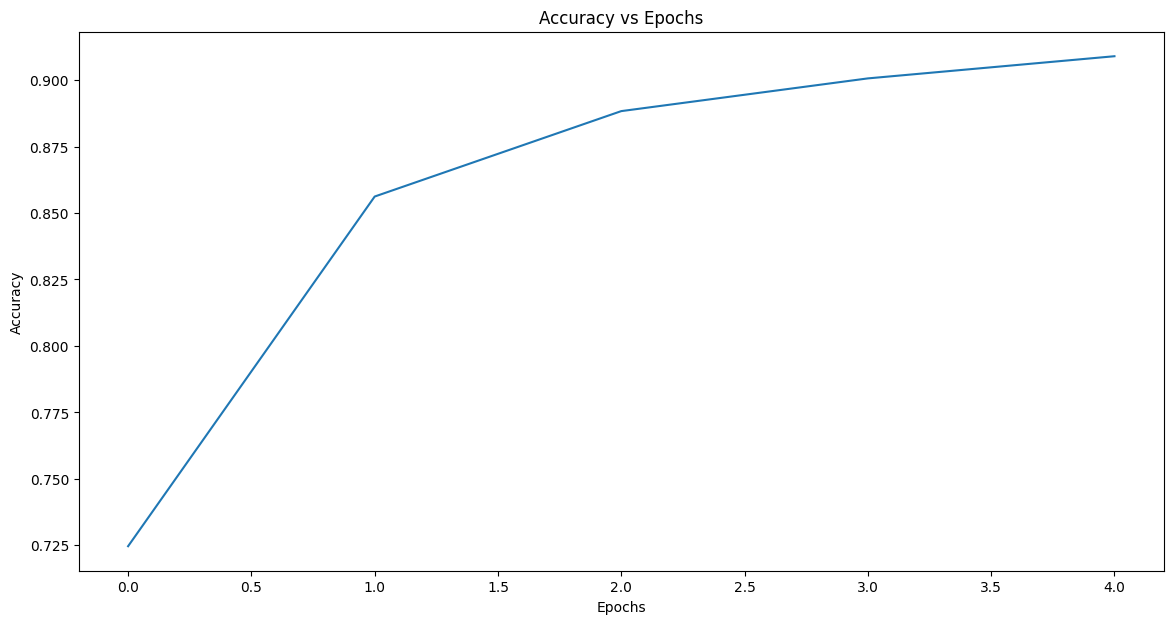

In [ ]:
accuracy = history.history['accuracy']
plt.figure(figsize=(14,7))
plt.plot(accuracy)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.show()

In [ ]:
pathSaved = r"/content/drive/MyDrive/X-Ray_Image_Classification/chest_xray/models_10.h5"
xray_model.save(pathSaved)

In [ ]:
def prepare_img(image):
  test_img_array = cv2.imread(image , cv2.IMREAD_GRAYSCALE)
  new_test_img_array = cv2.resize(test_img_array , (img_size , img_size))
  return new_test_img_array

In [ ]:
model = tf.keras.models.load_model("/content/drive/MyDrive/X-Ray_Image_Classification/chest_xray/models_10.h5") #if it exists in drive then this will just replace the existing one with new one

In [ ]:
img_temp_test = "/content/drive/MyDrive/X-Ray_Image_Classification/chest_xray/test/NORMAL/NORMAL-4512-0001.jpeg"

processed = prepare_img(img_temp_test)                      # actually read + resize the image
processed = processed.reshape(1, img_size, img_size, 1) / 255   # add batch & channel dims, normalize

prediction = model.predict(processed)
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
[[0.12337419]]
0
NORMAL


In [ ]:
X_test = []
Y_test = []
testing_data = []

In [ ]:
def create_testing_data():
  for i in CATEGORIES:
    path = os.path.join(DATA_DIR_test , i)
    testIndex = CATEGORIES.index(i)
    for img in os.listdir(path) :
      img_test_array = cv2.imread(os.path.join(path , img) , cv2.IMREAD_GRAYSCALE)
      new_test_array = cv2.resize(img_test_array , (img_size,img_size))
      testing_data.append([new_test_array,testIndex])

In [ ]:
create_testing_data()

In [ ]:
for features , label in testing_data :
  X_test.append(features)
  Y_test.append(label)

In [ ]:
X_test = np.array(X_test).reshape(-1,img_size,img_size,1)
Y_test = np.array(Y_test)

In [ ]:
X_test = X_test / 255

In [ ]:
evaluation_loss , evaluation_accuracy = model.evaluate(X_test , Y_test)
print(evaluation_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 350ms/step - accuracy: 0.8597 - loss: 0.3023
0.8596774339675903


In [ ]:
import tensorflow_model_optimizations as tfmot

q_model = tf.quantization.keras.quantize_model(xray_model)

In [ ]:
q_model.compile(optimizer="adam" , loss="binary_crossentropy" , metrics = ["accuracy"])

In [ ]:
q_model.fit(X_train , Y_train , epochs=1)
q_model.evaluate(X_test , Y_test)

In [ ]:
converter = tf.lite.TFLiteConverter(q_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()